# Basic Visualisation
```{admonition} Overview
:class: info

In this chapter, we create our **first visualisations** from the downloaded dataset.

---

# Learning goals

- Load and prepare spatial data for plotting  
- Reuse shared elements (e.g., borders)  
- Understand how simple maps communicate patterns  
- Improve visual clarity step by step  

---

# Why visualisation matters

Urban climate data is often complex and multi-dimensional.  
Visualisation helps to:

- Reveal **spatial patterns** (e.g., greener vs. hotter areas)  
- Compare **cities and regions**  
- Identify **outliers or unusual values**  
- Communicate results clearly for **decision-making**  

---

# Tables vs. Plots

- **Tables** → precise values and verification  
- **Plots** → patterns, trends, relationships  

Use tables for **accuracy**, plots for **understanding**

```{admonition} Common beginner mistakes
:class: tip, dropdown

- Plotting **too many variables** in **one chart**
- Ignoring time scale (daily vs. yearly data)
- Missing axis labels or units
- Using **misleading scales**
- **Overcrowding** maps with too many **labels**

Clear, focused, and transparent visualisations are essential in urban climate analysis, especially when results inform planning and policy decisions.
```

```{admonition} Load and Prepare the Data
:class: info, dropdown

In this step, we load the GeoPackage and prepare the dataset for visualisation.

The code will:

- Load the city-level spatial dataset
- Select the indicator column
- Convert the indicator values to numeric format
- Load country borders for orientation
- Prepare reusable map layers
- Create an output folder where maps will be saved
```

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patheffects as pe
from pathlib import Path
from IPython.display import display, HTML

# -----------------------------
# File paths
# -----------------------------

GPKG = "../../00_data/downloaded_data/climate_regulation_in_cities.gpkg"
WORLD = "../../00_data/downloaded_data/ne_110m_admin_0_countries.shp"

# Folder where exported maps will be saved
fig_dir = Path("../_static/outputs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load the dataset
# -----------------------------

gdf = gpd.read_file(GPKG)

# Columns used in the visualisations
value_col = "Pop_Benefit_Percent"
name_col = "GEN"

# Check required columns
if value_col not in gdf.columns:
    raise ValueError(f"Column '{value_col}' not found. Available columns: {list(gdf.columns)}")

if name_col not in gdf.columns:
    raise ValueError(f"Column '{name_col}' not found. Available columns: {list(gdf.columns)}")

# Ensure the indicator column is numeric
gdf[value_col] = pd.to_numeric(gdf[value_col], errors="coerce")

# Convert to WGS84 for overlay with country boundaries
gdf_wgs = gdf.to_crs("EPSG:4326")

# Load world / country boundaries
world = gpd.read_file(WORLD).to_crs("EPSG:4326")

# Select Germany
germany = world[world["NAME"] == "Germany"]

# Define map extent around Germany
minx, miny, maxx, maxy = germany.total_bounds
pad_x, pad_y = 3.5, 2.5
extent = (minx - pad_x, maxx + pad_x, miny - pad_y, maxy + pad_y)

# Select nearby countries for context
nearby = world.cx[extent[0]:extent[1], extent[2]:extent[3]]

# Reusable borders
city_borders = gdf_wgs.boundary
main_outline = gdf_wgs.dissolve().boundary

print("Data loaded successfully.")
print("Number of cities:", len(gdf_wgs))
print("Columns:", list(gdf_wgs.columns))
print("Maps will be saved to:", fig_dir)

Data loaded successfully.
Number of cities: 165
Columns: ['AGS', 'GEN', 'NUTS', 'Shape_Leng', 'Shape_Area', 'Pop_Benefit_Percent', 'geometry']
Maps will be saved to: ../_static/outputs/figures


```{admonition} Quick Exploratory Map
:class: info, dropdown

The first map gives a quick overview of the indicator values.

This map is useful for initial exploration, but it is not yet publication-ready.

It includes:

- The main climate-regulation indicator
- A simple color scale
- A Germany outline for orientation
- A short source caption
```

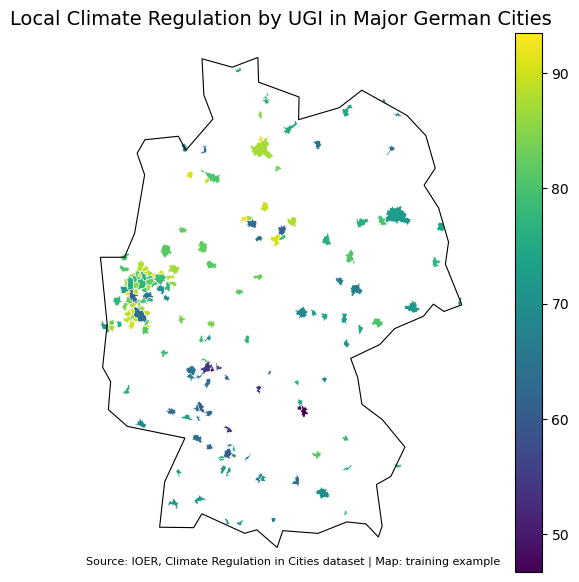

In [3]:
fig, ax = plt.subplots(figsize=(9, 7))

gdf_wgs.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)

# Germany border for orientation
germany.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8
)

ax.set_title(
    "Local Climate Regulation by UGI in Major German Cities",
    fontsize=14,
    fontweight="regular"
)

ax.text(
    0.01,
    0.01,
    "Source: IOER, Climate Regulation in Cities dataset | Map: training example",
    transform=ax.transAxes,
    fontsize=8,
    ha="left",
    va="bottom"
)

ax.set_axis_off()

plt.show()

```{admonition} Interpreting the Exploratory Map
:class: tip, dropdown

This map helps us identify general spatial patterns.

However, it still has some limitations:

- It has limited geographic context
- It does not show neighboring countries
- It does not label important cities
- The layout could be improved for communication

Next, we create a more polished final map.
```

```{admonition} What Happens If We Label Every City?
:class: warning

A common beginner mistake is to add **too many labels** to a map.

In the next map, we label **all cities** to intentionally show what clutter looks like.

This helps us understand why cartographic design often requires selection and simplification.
```

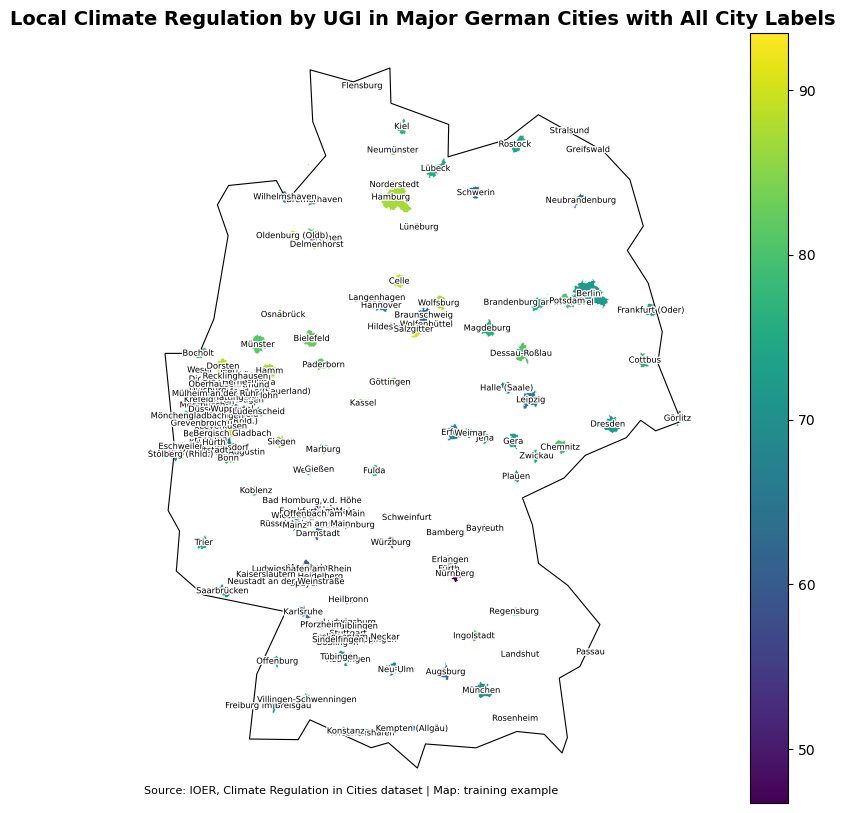

In [4]:
fig, ax = plt.subplots(figsize=(11, 10))

gdf_wgs.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)

# Germany border for orientation
germany.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8
)

# Add all city labels
label_points = gdf_wgs.geometry.representative_point()

for x, y, name in zip(label_points.x, label_points.y, gdf_wgs[name_col].astype(str)):
    txt = ax.text(
        x,
        y,
        name,
        fontsize=6,
        ha="center",
        va="center",
        color="black"
    )
    txt.set_path_effects([
        pe.withStroke(linewidth=2, foreground="white")
    ])

ax.set_title(
    "Local Climate Regulation by UGI in Major German Cities with All City Labels",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.01,
    0.01,
    "Source: IOER, Climate Regulation in Cities dataset | Map: training example",
    transform=ax.transAxes,
    fontsize=8,
    ha="left",
    va="bottom"
)

ax.set_axis_off()
plt.show()

```{admonition} Interpreting the Cluttered Map
:class: tip, dropdown

This map contains useful information, but it is difficult to read.

---

# What we notice

- Many city names overlap
- Labels compete with the data layer
- The visual pattern becomes harder to understand
- The map looks crowded, especially in dense urban regions

---

# Design lesson

More information does **not always** mean better communication.

In the next map, we reduce clutter by labelling only selected major cities.
```

```{admonition} Decluttured Map
:class: info, dropdown

This map improves the exploratory version by adding:

- A descriptive title
- Germany and neighboring countries for orientation
- Selected city labels
- A clean visual hierarchy
- Source and copyright information
- Export-ready layout

To avoid clutter, we label only selected major cities.
```

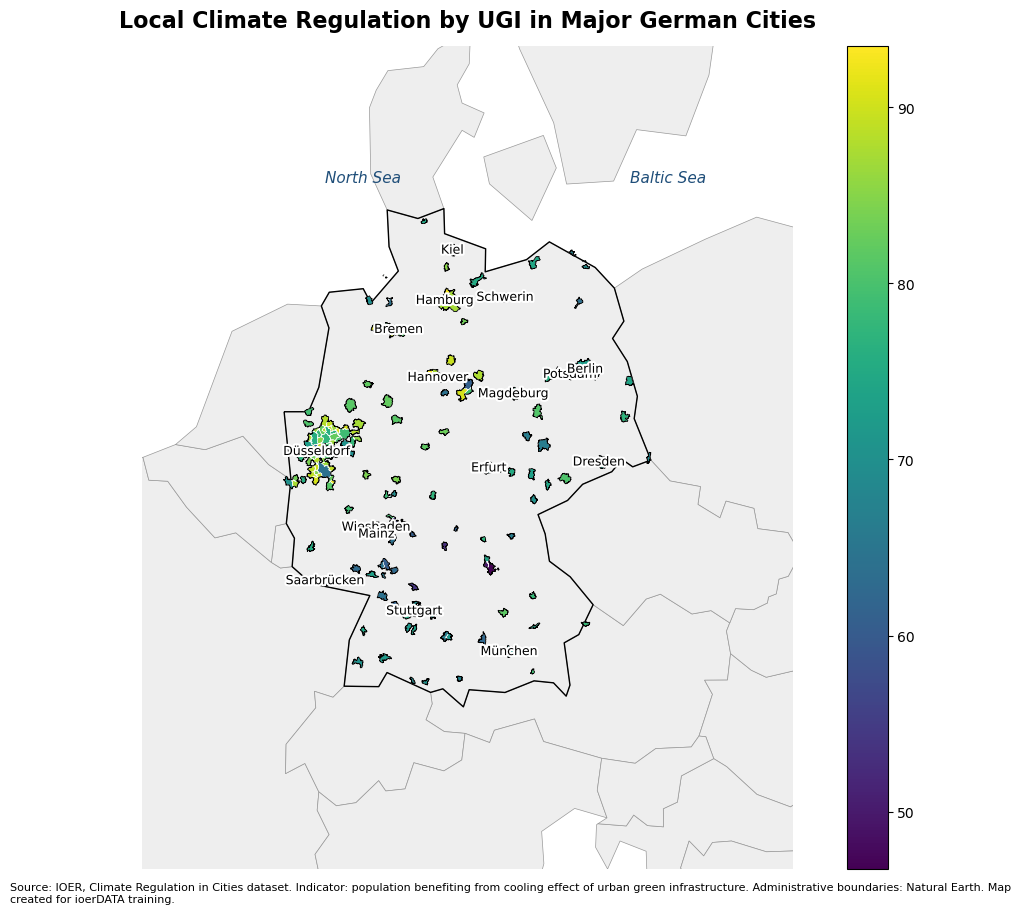

In [5]:
# Selected city labels to avoid overcrowding
major_cities = {
    "Hamburg", "Berlin", "München", "Stuttgart", "Dresden",
    "Bremen", "Hannover", "Kiel", "Schwerin", "Potsdam",
    "Magdeburg", "Erfurt", "Wiesbaden", "Mainz",
    "Saarbrücken", "Düsseldorf"
}

label_gdf = gdf_wgs[gdf_wgs[name_col].astype(str).isin(major_cities)].copy()

fig, ax = plt.subplots(figsize=(11, 10))

# Sea / background
ax.set_facecolor("#dceef7")

# Neighboring countries
nearby.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="#999999",
    linewidth=0.5,
    zorder=1
)

# Germany border
germany.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.0,
    zorder=2
)

# Main thematic layer
gdf_wgs.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "Missing"},
    zorder=3
)

# City boundaries
city_borders.plot(
    ax=ax,
    linewidth=0.35,
    color="white",
    alpha=0.9,
    zorder=4
)

# Outer outline of the dataset
main_outline.plot(
    ax=ax,
    linewidth=0.6,
    color="black",
    zorder=5
)

# City labels with white halo
pts = label_gdf.geometry.representative_point()

for x, y, name in zip(pts.x, pts.y, label_gdf[name_col]):
    label = ax.text(
        x,
        y,
        name,
        fontsize=9,
        ha="center",
        va="center",
        color="black",
        zorder=10
    )
    label.set_path_effects([
        pe.withStroke(linewidth=3, foreground="white")
    ])

# Orientation labels
ax.text(7.0, 55.4, "North Sea", fontsize=11, fontstyle="italic", color="#1f4e79")
ax.text(14.5, 55.4, "Baltic Sea", fontsize=11, fontstyle="italic", color="#1f4e79")

# Extent
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Descriptive title
ax.set_title(
    "Local Climate Regulation by UGI in Major German Cities",
    fontsize=16,
    fontweight="bold",
    pad=14
)

# Caption / source information
caption = (
    "Source: IOER, Climate Regulation in Cities dataset. "
    "Indicator: population benefiting from cooling effect of urban green infrastructure. "
    "Administrative boundaries: Natural Earth. "
    "Map created for ioerDATA training."
)

fig.text(
    0.08,
    0.04,
    caption,
    ha="left",
    va="bottom",
    fontsize=8,
    wrap=True
)

ax.set_axis_off()

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

```{admonition} Automatic Selection of Top Cities
:class: info, dropdown

Instead of manually choosing cities, we can let the data decide which ones to label.

Here, we automatically select the **top cities based on the indicator value**.

This helps us:

- reduce manual choices
- avoid overcrowding
- highlight the strongest indicator values
- make the method easier to repeat with other datasets
```

Automatically selected 15 cities:
['Berlin', 'Hamburg', 'Köln', 'Dresden', 'Bremen', 'München', 'Münster', 'Leipzig', 'Dortmund', 'Erfurt', 'Bielefeld', 'Frankfurt am Main', 'Dessau-Roßlau', 'Duisburg', 'Brandenburg an der Havel']


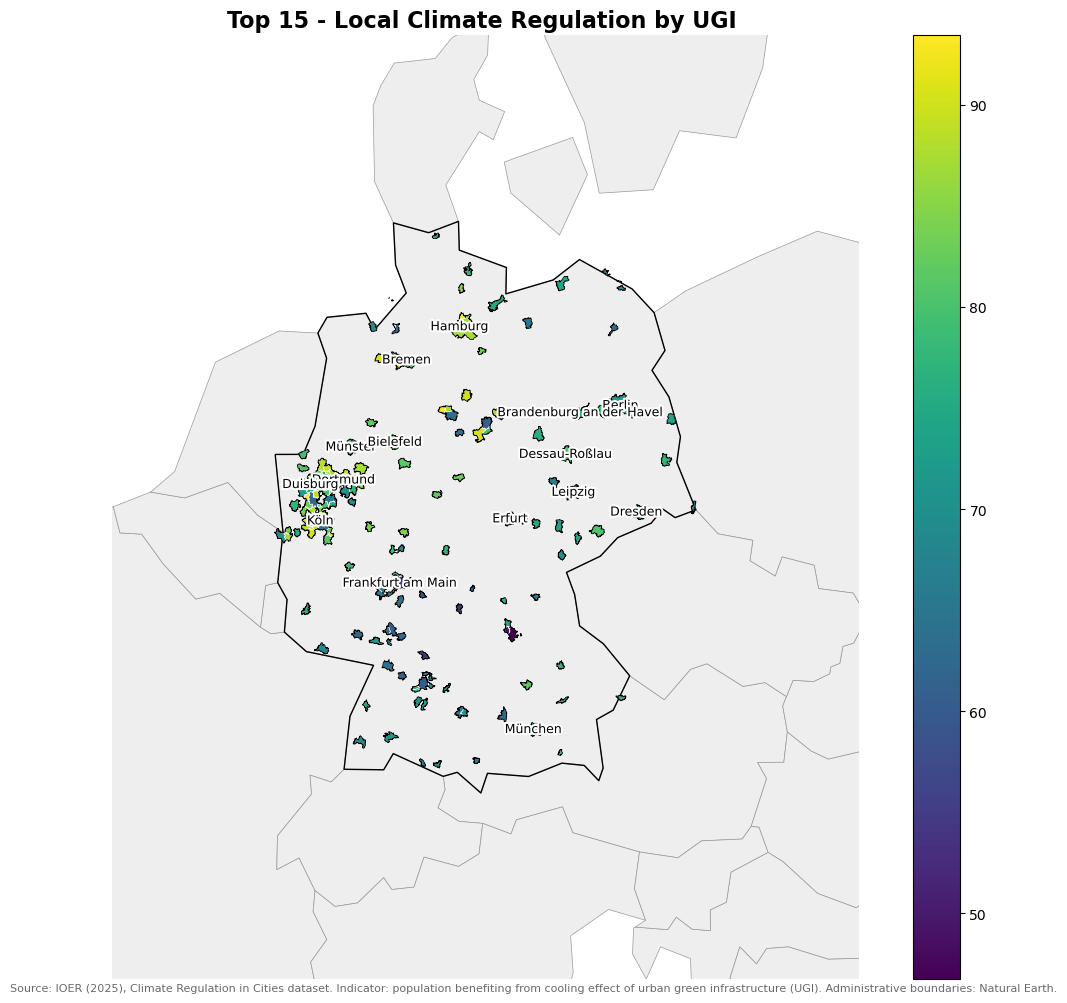

In [17]:
# Automatically select the largest city polygons
N_LABELS = 15

affected = gdf_wgs[gdf_wgs[value_col].fillna(0) > 0].copy()

# Use projected data for area calculation to avoid inaccurate area values in WGS84
affected_projected = affected.to_crs(gdf.crs)
affected["_area_m2"] = affected_projected.geometry.area

# Select the largest polygons
label_gdf = affected.nlargest(N_LABELS, "_area_m2").copy()

print(f"Automatically selected {len(label_gdf)} cities:")
print(label_gdf[name_col].tolist())

fig, ax = plt.subplots(figsize=(11, 10))

# Reuse existing map layers
ax.set_facecolor("#dceef7")
nearby.plot(ax=ax, color="#eeeeee", edgecolor="#999999", linewidth=0.5, zorder=1)
germany.boundary.plot(ax=ax, color="black", linewidth=1.0, zorder=2)

gdf_wgs.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    missing_kwds={"color": "lightgrey"},
    zorder=3
)

city_borders.plot(ax=ax, linewidth=0.35, color="white", alpha=0.9, zorder=4)
main_outline.plot(ax=ax, linewidth=0.6, color="black", zorder=5)

# Add labels for automatically selected cities
pts = label_gdf.geometry.representative_point()

for x, y, name in zip(pts.x, pts.y, label_gdf[name_col]):
    txt = ax.text(
        x, y, name,
        fontsize=9,
        ha="center",
        va="center",
        color="black",
        zorder=10
    )
    txt.set_path_effects([
        pe.withStroke(linewidth=3, foreground="white")
    ])

ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

ax.set_title(
    f"Top {N_LABELS} - Local Climate Regulation by UGI ",
    fontsize=16,
    fontweight="bold"
)

ax.set_axis_off()
plt.tight_layout()

# Caption / source information
caption = (
    "Source: IOER (2025), Climate Regulation in Cities dataset. "
    "Indicator: population benefiting from cooling effect of urban green infrastructure (UGI). "
    "Administrative boundaries: Natural Earth."
)

fig.text(
    0.02, 0.001,   # left-bottom corner
    caption,
    ha="left",
    va="bottom",
    fontsize=8,
    color="dimgray"
)
plt.show()

```{admonition} Interpreting the Automatically Labelled Map
:class: tip, dropdown

This map labels the cities with the highest values of the selected indicator.

---

# What changed?

- Labels are selected automatically
- The map is less crowded than the all-label version
- The labelled cities are directly linked to the data values
- The method can be reused with another indicator or dataset

---

# Design lesson

Automatic labelling can make maps more reproducible and transparent.

However, the “top” cities are not always the most useful reference points for orientation.

For final communication maps, combine **data-driven selection** with **cartographic judgement**.
```

```{admonition} Save the Final Map
:class: info, dropdown

The next cell saves the final map as both:

- **PNG** — useful for websites, slides, and reports
- **PDF** — useful for print and high-quality documents

The files are saved inside:

`../_static/outputs/figures/`

This folder can be included in the Jupyter Book build, so learners can download the map from the published training page.
```

In [18]:
# Output file paths
output_png = fig_dir / "local_climate_regulation_ugi_major_german_cities.png"
output_pdf = fig_dir / "local_climate_regulation_ugi_major_german_cities.pdf"

# Save figures
fig.savefig(output_png, dpi=300, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")

print("Saved map files:")
print(output_png)
print(output_pdf)

Saved map files:
../_static/outputs/figures/local_climate_regulation_ugi_major_german_cities.png
../_static/outputs/figures/local_climate_regulation_ugi_major_german_cities.pdf


```{admonition}️ Download the Map
:class: tip, dropdown

Use the buttons below to download the final map.

The PNG version is recommended for presentations and web pages.  
The PDF version is recommended for print or high-quality reports.
```

In [19]:
display(HTML(f"""
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="{output_png}" download
       style="
           display: inline-block;
           background-color: #2E7D32;
           color: white;
           padding: 10px 14px;
           text-decoration: none;
           border-radius: 6px;
           font-weight: bold;
           margin-right: 10px;
       ">
       ⬇️ Download PNG
    </a>

    <a href="{output_pdf}" download
       style="
           display: inline-block;
           background-color: #1565C0;
           color: white;
           padding: 10px 14px;
           text-decoration: none;
           border-radius: 6px;
           font-weight: bold;
       ">
       ⬇️ Download PDF
    </a>

</div>
"""))

```{admonition} Overall Takeaway
:class: tip

In this chapter, we transformed a basic map into a clearer and more informative visualisation.

We improved the map by:

- Adding geographic context
- Using a descriptive title
- Reducing label clutter
- Including source information
- Saving the output for reuse
- Providing download links for learners

---

In the next chapter, we will explore **advanced visualisations** for deeper spatial insight.
```